In [1]:
from dotenv import load_dotenv

load_dotenv()

True

## Summarize messages

Middleware is code that sits in the middle of an agent's loop and can inspect or change what goes into or comes out of each step, such as the model call or tool call, without changing the agent itself. For example, SummarizationMiddleware quietly shortens the conversation history before each model call, so you can add features like that, plus things like guardrails and logging, by plugging them in. This is an instance of node-style middleware, which is good at hooking into the agent and changing its state.

In [2]:
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents.middleware import SummarizationMiddleware

agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware( 
            model="google_genai:gemini-3.1-flash-lite", # Specify model to summarize the conversation
            trigger=("tokens", 100), # Specify the amount of tokens that you allow your conversation to grow to until a value where we start summarizing
            keep=("messages", 1) # Specify the number of messages to keep after summarizing. The rest will be deleted.
        )
    ],
)

In [3]:
from langchain.messages import HumanMessage, AIMessage
from pprint import pprint

# In this example, there is a back and forth conversation between the Human and the AI
response = agent.invoke(
    {"messages": [
        HumanMessage(content="What is the capital of the moon?"),
        AIMessage(content="The capital of the moon is Lunapolis."),
        HumanMessage(content="What is the weather in Lunapolis?"),
        AIMessage(content="Skies are clear, with a high of 120C and a low of -100C."),
        HumanMessage(content="How many cheese miners live in Lunapolis?"),
        AIMessage(content="There are 100,000 cheese miners living in Lunapolis."),
        HumanMessage(content="Do you think the cheese miners' union will strike?"),
        AIMessage(content="Yes, because they are unhappy with the new president."),
        HumanMessage(content="If you were Lunapolis' new president how would you respond to the cheese miners' union?"),
        ]},
    {"configurable": {"thread_id": "1"}}
)

pprint(response)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'messages': [HumanMessage(content='Here is a summary of the conversation to date:\n\n## SESSION INTENT\n\nThe user is inquiring about fictional details regarding the moon, specifically the city of Lunapolis, its climate, its population of cheese miners, and the current state of labor relations within the city.\n\n## SUMMARY\n\n*   **Location:** Lunapolis is established as the capital of the moon.\n*   **Climate:** The environment experiences extreme temperature fluctuations, ranging from 120°C to -100°C with clear skies.\n*   **Demographics:** Lunapolis has a population of 100,000 "cheese miners."\n*   **Labor Relations:** A strike by the cheese miners\' union is anticipated due to dissatisfaction with the current president.\n\n## ARTIFACTS\n\nNone.\n\n## NEXT STEPS\n\nAwait further inquiries from the user regarding Lunapolis, the cheese mining industry, or other moon-related information.', additional_kwargs={'lc_source': 'summarization'}, response_metadata={}, id='55e516fc-500d-46ca-

- Notice the first message is the summarized conversation to date. It does a fairly good job at summarizing the conversation.
- It then keeps the final message because we specified for the summarization middleware to keep 1 message before answering the question.
- With this implementation, you are able to summarize the conversation and only keep 1 message.

In [4]:
print(response["messages"][0].content)

Here is a summary of the conversation to date:

## SESSION INTENT

The user is inquiring about fictional details regarding the moon, specifically the city of Lunapolis, its climate, its population of cheese miners, and the current state of labor relations within the city.

## SUMMARY

*   **Location:** Lunapolis is established as the capital of the moon.
*   **Climate:** The environment experiences extreme temperature fluctuations, ranging from 120°C to -100°C with clear skies.
*   **Demographics:** Lunapolis has a population of 100,000 "cheese miners."
*   **Labor Relations:** A strike by the cheese miners' union is anticipated due to dissatisfaction with the current president.

## ARTIFACTS

None.

## NEXT STEPS

Await further inquiries from the user regarding Lunapolis, the cheese mining industry, or other moon-related information.


## Trim/delete messages

There may be situations where you want to entirely remove messages, or have granular control over what messages get deleted rather than just the oldest. This is another instance of node-style middleware, which is good at hooking into the agent and changing its state.
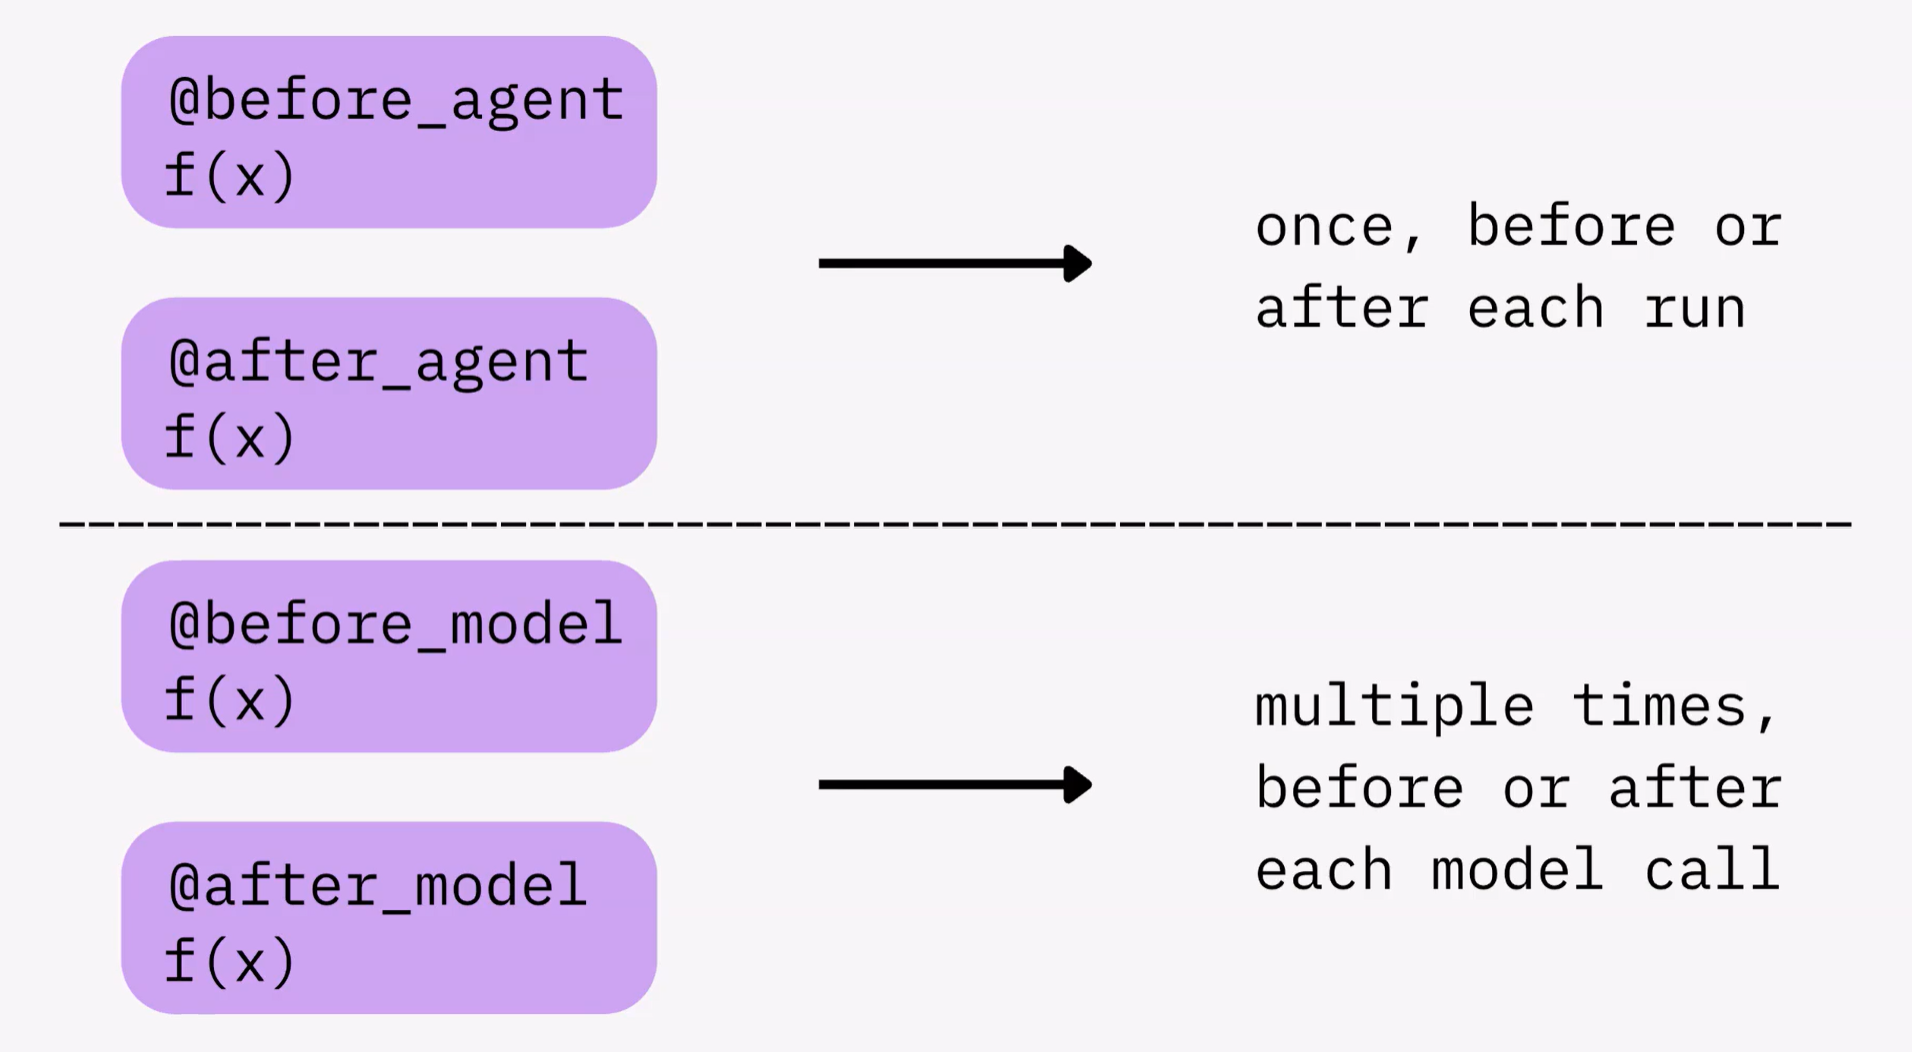

In [5]:
from typing import Any
from langchain.agents import AgentState
from langchain.messages import RemoveMessage
from langgraph.runtime import Runtime
from langchain.agents.middleware import before_agent
from langchain.messages import ToolMessage

@before_agent # The before agent decorator
def trim_messages(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Remove all the tool messages from the state"""
    messages = state["messages"]

    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    
    return {"messages": [RemoveMessage(id=m.id) for m in tool_messages]}

In [6]:
agent = create_agent(
    model="google_genai:gemini-3.1-flash-lite",
    checkpointer=InMemorySaver(),
    middleware=[trim_messages],
)

In [7]:
# In this example, there is a back and forth conversation regarding customer technical support issue, with a few gibberish tool messages that do not really help the agent at all
# Removing the tool messages will remove noise too

response = agent.invoke(
    {"messages": [
        HumanMessage(content="My device won't turn on. What should I do?"),
        ToolMessage(content="blorp-x7 initiating diagnostic ping…", tool_call_id="1"),
        AIMessage(content="Is the device plugged in and turned on?"),
        HumanMessage(content="Yes, it's plugged in and turned on."),
        ToolMessage(content="temp=42C voltage=2.9v … greeble complete.", tool_call_id="2"),
        AIMessage(content="Is the device showing any lights or indicators?"),
        HumanMessage(content="What's the temperature of the device?")
        ]},
    {"configurable": {"thread_id": "2"}}
)

pprint(response)

{'messages': [HumanMessage(content="My device won't turn on. What should I do?", additional_kwargs={}, response_metadata={}, id='4a0d4bb8-d5ed-4716-b87a-15d56127e27e'),
              AIMessage(content='Is the device plugged in and turned on?', additional_kwargs={}, response_metadata={}, id='a416d7e7-43ce-40af-9d10-204cef914442', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content="Yes, it's plugged in and turned on.", additional_kwargs={}, response_metadata={}, id='bacd92ac-6d8e-4178-94a5-7fe7318aaa53'),
              AIMessage(content='Is the device showing any lights or indicators?', additional_kwargs={}, response_metadata={}, id='bc85a7b4-b261-4393-8729-db932402ee3b', tool_calls=[], invalid_tool_calls=[]),
              HumanMessage(content="What's the temperature of the device?", additional_kwargs={}, response_metadata={}, id='45e7b04b-0bea-4190-8dcd-6cb4d87dad45'),
              AIMessage(content=[{'type': 'text', 'text': 'I am an AI, so I don\'t have a physi

The tool messages have been removed before they reached the agent itself because of the before_agent decorator. This is verified through the last AI message, which reflects that the agent does not have context regarding the temperature of the device as specified in the tool message.

In [9]:
print(response["messages"][-1].content[0]['text'])

I am an AI, so I don't have a physical presence to touch your device, and I cannot "see" it through your screen.

**To help you troubleshoot, you need to check the temperature yourself.**

Since the device won't turn on:

1.  **Check for Overheating:** Carefully touch the back or the bottom of the device (where the battery or processor is). Does it feel hot to the touch? If it feels excessively hot, it may have shut down to protect itself. **Unplug it immediately** and let it cool down for at least 30 minutes before trying to turn it on again.
2.  **Check for Extreme Cold:** If the device was left in a very cold environment (like a car overnight in winter), it may not turn on because the battery chemistry is temporarily stalled. Bring it into a room-temperature environment and let it acclimate for an hour before trying again.

**If the temperature seems normal (room temperature):**

*   **Try a "Hard Reset":** Most devices have a way to force a restart when they are unresponsive. 
    